In [1]:
#import math
#import numpy as np
import dateutil as du
import pandas as pd
#import datetime
%matplotlib inline
import matplotlib.pyplot as plt
#import matplotlib.patches as patches
#from metpy.plots import StationPlot #, sky_cover, current_weather
#from metpy.units import units

import modules.URLhandler as URLhandler
import modules.feelsLikeCalc as fLCalc

In [ ]:
# Rounding is performed because the API can't handle precision higher than 4 places.
lat = round(float(input("Enter the latitude of the city (e.g. Ames: 42.00, KOWA: 44.12):")), 4)
lon = round(float(input("Enter the longitude of the city (e.g. Ames: -93.62, KOWA: -93.26):")), 4)

# Longitude is never positive within the United States.
# Latitude should never be negative either.
if(lon > 0): lon *= -1
lat = abs(lat)

In [71]:
api_URL = "https://api.open-meteo.com/v1/forecast?latitude=42.0347&longitude=-93.6199&hourly=temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,cloud_cover&temperature_unit=fahrenheit&wind_speed_unit=mph&precipitation_unit=inch&models=gfs_global,gfs_hrrr,ncep_nbm_conus,gfs_graphcast025"

dataNOAA = URLhandler.URLcollectorJSON(api_URL, "NOAA forecast data")

In [72]:
print(dataNOAA['hourly'].keys())

dict_keys(['time', 'temperature_2m_gfs_global', 'relative_humidity_2m_gfs_global', 'dew_point_2m_gfs_global', 'apparent_temperature_gfs_global', 'cloud_cover_gfs_global', 'temperature_2m_gfs_hrrr', 'relative_humidity_2m_gfs_hrrr', 'dew_point_2m_gfs_hrrr', 'apparent_temperature_gfs_hrrr', 'cloud_cover_gfs_hrrr', 'temperature_2m_ncep_nbm_conus', 'relative_humidity_2m_ncep_nbm_conus', 'dew_point_2m_ncep_nbm_conus', 'apparent_temperature_ncep_nbm_conus', 'cloud_cover_ncep_nbm_conus', 'temperature_2m_gfs_graphcast025', 'relative_humidity_2m_gfs_graphcast025', 'dew_point_2m_gfs_graphcast025', 'apparent_temperature_gfs_graphcast025', 'cloud_cover_gfs_graphcast025'])


In [73]:
NOAAdataLength = len(dataNOAA['hourly']['time'])

In [74]:
# Naming here makes it much easier to handle in the event I want to change the names.
timeName = "timestamp"
temperatureName = "temperature"
dewpointName = "dewpoint"
rhName = "relativeHumidity"
heatIndexName = "heatIndex"
windChillName = "windChill"
cloudCoverName = "cloudCover"
popName = "probabilityOfPrecip"
windDirName = "windDirection"
windSpeedName = "windSpeed"
nightName = "nighttimes"
precipTypesName = "precipType"

In [75]:
dictForecast = {timeName:        [None]*NOAAdataLength,
                temperatureName: [None]*NOAAdataLength,
                dewpointName:    [None]*NOAAdataLength,
                rhName:          [None]*NOAAdataLength,
                cloudCoverName:  [None]*NOAAdataLength}

GFSdataframe = pd.DataFrame(dictForecast)
GFS_GCdataframe = pd.DataFrame(dictForecast)
HRRRdataframe = pd.DataFrame(dictForecast)
NBMdataframe = pd.DataFrame(dictForecast)

In [93]:
GFSdataframe[timeName]        = dataNOAA['hourly']['time']
GFSdataframe[temperatureName] = dataNOAA['hourly']['temperature_2m_gfs_global']
GFSdataframe[dewpointName]    = dataNOAA['hourly']['dew_point_2m_gfs_global']
GFSdataframe[rhName]          = dataNOAA['hourly']['relative_humidity_2m_gfs_global']
GFSdataframe[cloudCoverName]  = dataNOAA['hourly']['cloud_cover_gfs_global']

In [94]:
GFS_GCdataframe[timeName]        = dataNOAA['hourly']['time']
GFS_GCdataframe[temperatureName] = dataNOAA['hourly']['temperature_2m_gfs_graphcast025']
GFS_GCdataframe[dewpointName]    = dataNOAA['hourly']['dew_point_2m_gfs_graphcast025']
GFS_GCdataframe[rhName]          = dataNOAA['hourly']['relative_humidity_2m_gfs_graphcast025']
GFS_GCdataframe[cloudCoverName]  = dataNOAA['hourly']['cloud_cover_gfs_graphcast025']

In [95]:
NBMdataframe[timeName]        = dataNOAA['hourly']['time']
NBMdataframe[temperatureName] = dataNOAA['hourly']['temperature_2m_ncep_nbm_conus']
NBMdataframe[dewpointName]    = dataNOAA['hourly']['dew_point_2m_ncep_nbm_conus']
NBMdataframe[rhName]          = dataNOAA['hourly']['relative_humidity_2m_ncep_nbm_conus']
NBMdataframe[cloudCoverName]  = dataNOAA['hourly']['cloud_cover_ncep_nbm_conus']

In [96]:
if(type(GFSdataframe[timeName][0]) != pd._libs.tslibs.timestamps.Timestamp):
    GFSdataframe[timeName] = [du.parser.parse(x) for x in GFSdataframe[timeName]]

if(type(GFS_GCdataframe[timeName][0]) != pd._libs.tslibs.timestamps.Timestamp):
    GFS_GCdataframe[timeName] = [du.parser.parse(x) for x in GFS_GCdataframe[timeName]]

if(type(NBMdataframe[timeName][0]) != pd._libs.tslibs.timestamps.Timestamp):
    NBMdataframe[timeName] = [du.parser.parse(x) for x in NBMdataframe[timeName]]

In [91]:
GFScolor = "royalblue"
GFS_GCcolor = "lightskyblue"
HRRRcolor = "forestgreen"
NBMcolor = "red"
linewidth = 1

Text(0, 0.5, 'Relative Humidity (%)')

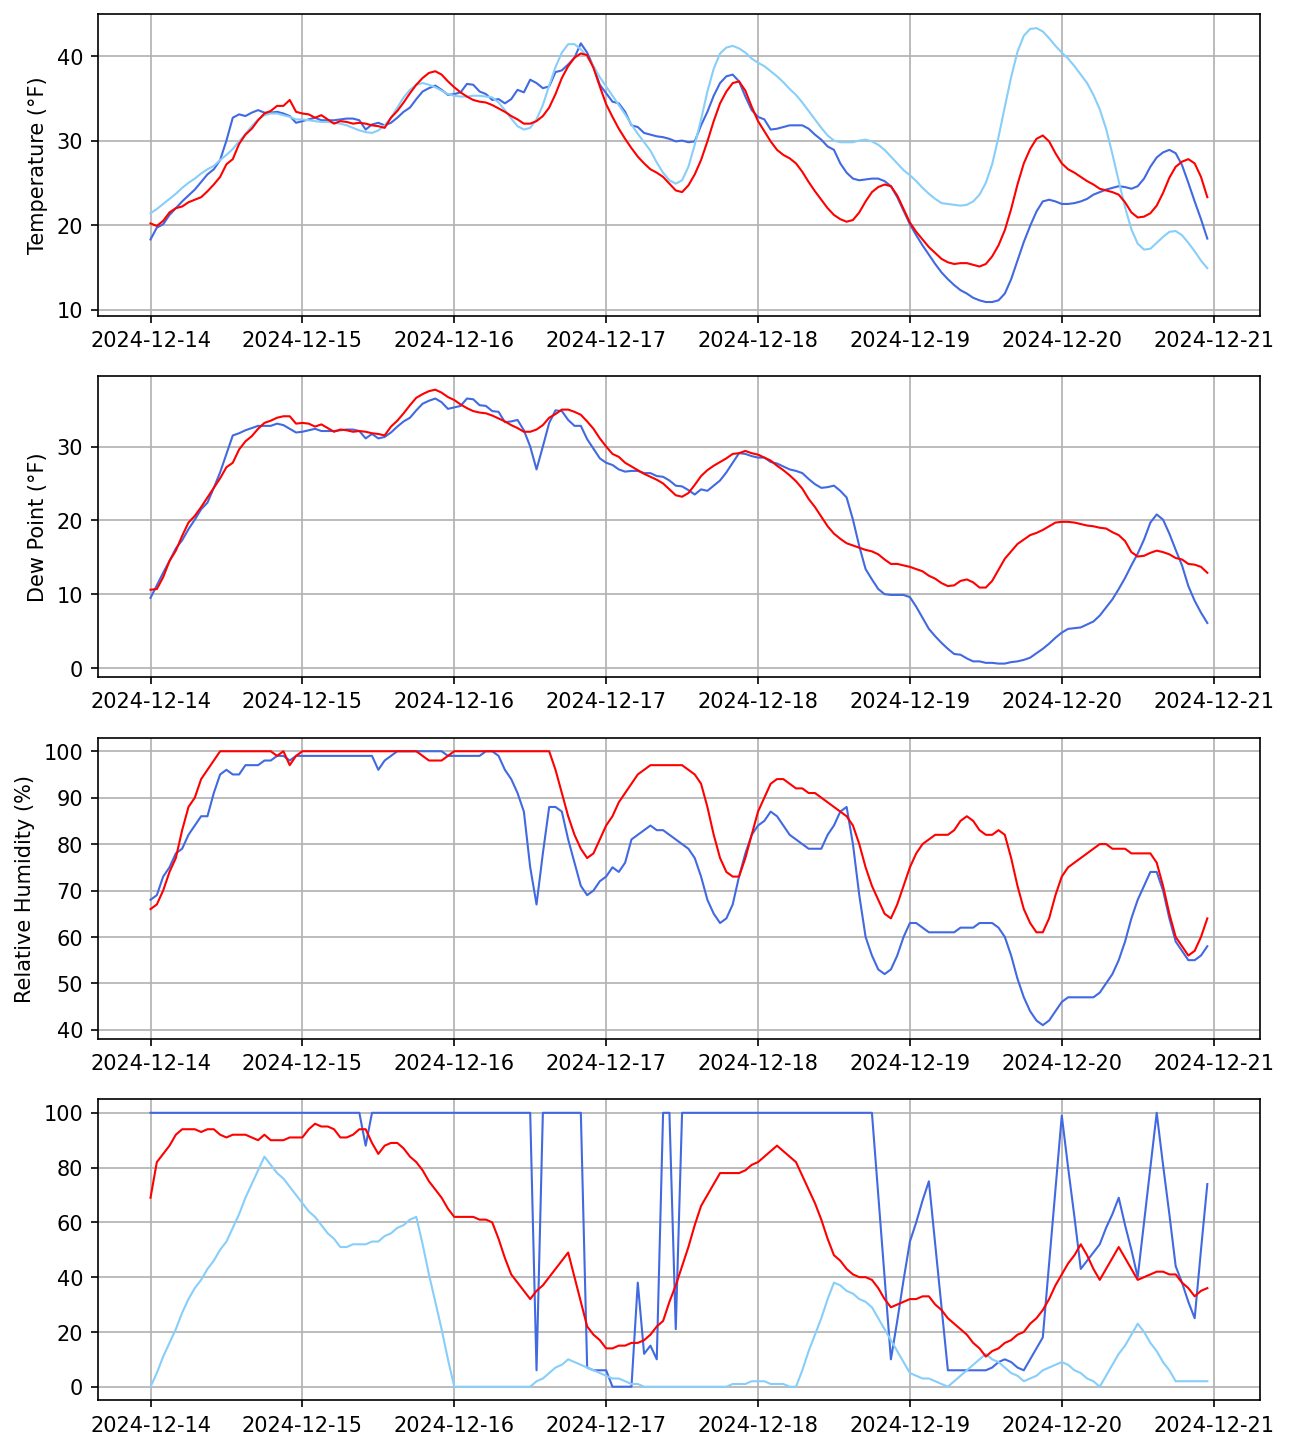

In [98]:
plt.rcParams["figure.dpi"] = 150
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(10,12))

ax1.plot(GFSdataframe[timeName], GFSdataframe[temperatureName], color=GFScolor, linewidth=linewidth)
ax1.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[temperatureName], color=GFS_GCcolor, linewidth=linewidth)
ax1.plot(NBMdataframe[timeName], NBMdataframe[temperatureName], color=NBMcolor, linewidth=linewidth)

ax2.plot(GFSdataframe[timeName], GFSdataframe[dewpointName], color=GFScolor, linewidth=linewidth)
ax2.plot(NBMdataframe[timeName], NBMdataframe[dewpointName], color=NBMcolor, linewidth=linewidth)

ax3.plot(GFSdataframe[timeName], GFSdataframe[rhName], color=GFScolor, linewidth=linewidth)
ax3.plot(NBMdataframe[timeName], NBMdataframe[rhName], color=NBMcolor, linewidth=linewidth)

ax4.plot(GFSdataframe[timeName], GFSdataframe[cloudCoverName], color=GFScolor, linewidth=linewidth)
ax4.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[cloudCoverName], color=GFS_GCcolor, linewidth=linewidth)
ax4.plot(NBMdataframe[timeName], NBMdataframe[cloudCoverName], color=NBMcolor, linewidth=linewidth)

ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)

ax1.set_ylabel("Temperature (°F)")
ax2.set_ylabel("Dew Point (°F)")
ax3.set_ylabel("Relative Humidity (%)")